# Simulating an Extended Source: Exozodiacal Disk

Local and exo-Zodiacal light are important astrophysical noise sources that must be considered when estimating integration times. Simulating zodiacal background sources is described in Notebook 04. The Simulation of an extended source has a similar logic, except here we treat the exozodi as the foreground source instead of the background noise, and integrate the exozodi's surface brightness over the coronograph's photometric aperture.


If running via Google Colab, you must first execute the contents of notebook `00_Google_Colab_Setup.ipynb` (only if you have never done so previously). Then execute all cells tagged with &#128992;.  If running via a local installation, you should skip all of the colab-specific (&#128992;) cells.

## 🟠 Setup for Google Colab Use

### 🟠 Run the next cell to mount the Google Drive

You will receive some or all of the following prompts:

* Warning: This notebook was not authored by Google - Click "Run Anyway" 
* Permit this notebook to access your Google Drive files? - Click "Connect to Google Drive"
* A new browser window will prompt you to select an account and authorize access
  * Select the Google account you wish to use and click Continue on each subsequent screen until the dialog vanishes

Upon completion of cell execution, you should see `Mounted at /content/drive`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 🟠 Run the next cell to change to the corgietc directory and install the required software

This process should take less than a minute, but, depending on bandwidth availability, may take as long as a few minutes. You will see a variety of messages about package downloads.  Upon completion of cell execution, you should see `Sucessfully installed` followed by a list of installed packages and their versions.

You may see the prompt "Restart session".  You do not need to do this - click 'Cancel'.

In [ ]:
# This cell should *only* be executed if running the notebook in Google Colab
import os

# Google top level drive dir
drive_dir = "/content/drive/MyDrive/"

# directory path
corgietc_dir = 'corgietc'
corgietc_path = os.path.join(drive_dir, corgietc_dir)
cgi_noise_repo_path = os.path.join(corgietc_path, "cgi_noise")
corgietc_repo_path = os.path.join(corgietc_path, "corgietc")
corgietc_notebooks_path = os.path.join(corgietc_repo_path, "Notebooks")

# Change to the cgi_noise repo path and update the repo
os.chdir(cgi_noise_repo_path)
!git pull

# Install the backend and all requirements - this can also take a little while
!pip install .

# Change to the corgietc repo path and update the repo
os.chdir(corgietc_repo_path)
!git pull

# Install the backend and all requirements - this can also take a little while
!pip install .

# Refresh package list to pick up new installations
import site
site.main()

# Change to the Notebooks directory
os.chdir(corgietc_notebooks_path)

### 🟠 Import jupyter widget for Colab

In [ ]:
# need to import third party jupyter widget
from google.colab import output
output.enable_custom_widget_manager()

## All Cells from this point should be run for both Colab and local installations

In [1]:
# import all required packages
from corgietc.corgietc import corgietc
import os
import json
import EXOSIMS.Prototypes.TargetList
import EXOSIMS.Prototypes.TimeKeeping
import EXOSIMS.Observatory.ObservatoryL2Halo
import copy
import astropy.units as u
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt

## Setup: Building the TargetList

We must start by loading the default `CGI_Noise.json` input specifications, as well as a `TargetList`

In [2]:
scriptfile = os.path.join(os.environ["CORGIETC_DATA_DIR"], "scripts", "CGI_Noise.json")
with open(scriptfile, "r") as f:
    specs = json.loads(f.read())
specs["modules"]["StarCatalog"] = "HWOMissionStars"
TL = EXOSIMS.Prototypes.TargetList.TargetList(**copy.deepcopy(specs))
ZL = TL.ZodiacalLight
OS = TL.OpticalSystem

/Users/ds264/Documents/gitrepos/EXOSIMS/EXOSIMS/Prototypes/TargetList.py:381: UserWarning: binary_filter is None but filterBinaries is False. Using binary_filter value of None.
  warnings.warn(


Imported HWOMissionStars (implementation) from EXOSIMS.StarCatalog.HWOMissionStars
Loaded data from /Users/ds264/.EXOSIMS/downloads/HWOStarList_20231019095442.pkl
Imported corgietc (named file) from /Users/ds264/Do[...]ietc/corgietc/corgietc.py
Imported Stark (implementation) from EXOSIMS.ZodiacalLight.Stark
Imported PostProcessing (prototype) from EXOSIMS.Prototypes.PostProcessing
Imported GalaxiesFaintStars (implementation) from EXOSIMS.BackgroundSources.GalaxiesFaintStars
Imported Completeness (prototype) from EXOSIMS.Prototypes.Completeness
Imported PlanetPopulation (prototype) from EXOSIMS.Prototypes.PlanetPopulation
Imported ForecasterMod (implementation) from EXOSIMS.PlanetPhysicalModel.ForecasterMod
164 targets imported from star catalog.
164 targets remain after removing those where spectral class cannot be established.
164 targets remain after removing white dwarfs and subdwarfs
164 targets remain after nan filtering.
164 targets remain after removing zero luminosity targets.

In this Notebook, we will work with the first observing mode and 47 UMa (HIP 53721) target. 

In [3]:
# Select observing mode and target
mode = OS.observingModes[0]
sInd = np.where(TL.Name == "HIP 53721")[0]

print(f"Observing mode: {mode['Scenario']}")
print(f"Central wavelength: {mode['lam']}")
print(f"Target: {TL.Name[sInd][0]}")

Observing mode: OPT_IMG_NFB1_HLC
Central wavelength: 575.0 nm
Target: HIP 53721


### The Coronagraph Photometric Aperture: `Omega`

For a point source like a planet, the signal is collected within the PSF core. The size of that core is captured by the coronagraph's `core_area`, which we call `Omega`. It has units of arcsec² and depends on both the observing wavelength and the working angle (separation from the star).

For an **extended source**, `Omega` plays a critical role: it is the solid angle over which the surface brightness is integrated to produce a count rate. The larger `Omega`, the more disk flux is collected.

Let's first define our working angle of interest and inspect the value of `Omega` at that location.

### Important note about `Omega` 

Coronagraph's `core_area` in corgietc, or `Omega`, goes through a transformation within the files which causes its units to be skewed. `Omega` when imported simply as syst["core_area"](lam, WA) does not have units of squared arecsecond. Therefore, starting from this point, Omega's units need to get converted, by dividing it with (syst["input_angle_unit_value"]/u.arcsec) ** 2. This converts the units of `Omega` to arcsec², and we are good to continue. 

In [4]:
# Define working angle in lambda/D units, then convert to arcseconds
WA = np.array([7.5]) * (mode["lam"] / OS.pupilDiam).to(
    u.arcsec, equivalencies=u.dimensionless_angles()
)
print(f"Working angle: {WA[0]:.4f}")

# Retrieve the coronagraph core area (photometric aperture) at this WA
syst = mode["syst"]
lam  = mode["lam"]
Omega = syst["core_area"](lam, WA)/ (syst["input_angle_unit_value"]/u.arcsec) ** 2 # convert to square arcseconds
print(f"Central wavelength: {lam}")
print(f"Coronagraph core area Omega = {Omega[0]:.2e}")

Working angle: 0.3764 arcsec
Central wavelength: 575.0 nm
Coronagraph core area Omega = 2.34e-03 arcsec2


We can also see how `Omega` varies as a function of working angle across the full coronagraph field. This illustrates that the effective aperture size changes with separation from the star.

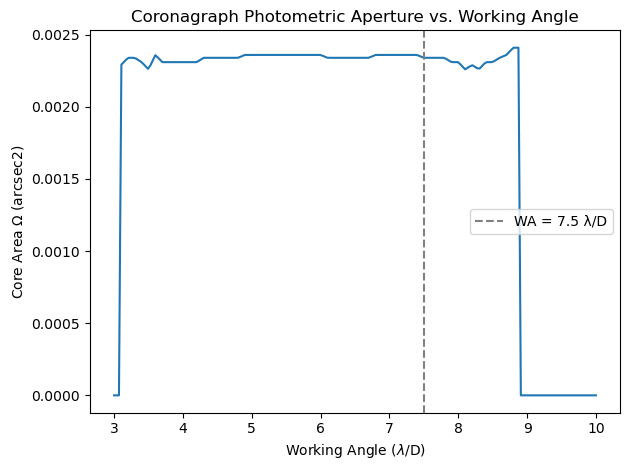

In [5]:
# Compute Omega across a range of working angles
lam_D = (mode["lam"] / OS.pupilDiam).to(u.arcsec, equivalencies=u.dimensionless_angles())
WA_range = np.linspace(3, 10, 200) * lam_D
Omega_range = syst["core_area"](lam, WA_range)/(syst["input_angle_unit_value"]/u.arcsec) ** 2 # convert to square arcseconds

plt.figure()
plt.plot(WA_range / lam_D, Omega_range)
plt.xlabel(r"Working Angle ($\lambda$/D)")
plt.ylabel(f"Core Area $\\Omega$ ({Omega_range.unit})")
plt.title("Coronagraph Photometric Aperture vs. Working Angle")
plt.axvline(7.5, color='gray', linestyle='--', label='WA = 7.5 λ/D')
plt.legend()
plt.tight_layout();

## Computing the Exozodiacal Surface Brightness

The surface brightness of the exozodiacal dust disk is described by the standard magnitude equation:

$$f_{Z,\mathrm{ez}} = F_0 \times 10^{-m_{\mathrm{EZ}}/2.5} \quad [\mathrm{ph\,s^{-1}\,m^{-2}\,nm^{-1}\,arcsec^{-2}}]$$

where:
- $F_0$ is the zero-magnitude spectral flux density for the observing band (`mode["F0"]`), i.e., the flux corresponding to a 0th magnitude source integrated over the bandpass
- $m_{\mathrm{EZ}} = 22$ mag/arcsec² is the default exozodi surface brightness from [Stark et al. (2014)](http://dx.doi.org/10.1088/0004-637X/795/2/122), also stored in `ZL.magEZ`

This is entirely analogous to the local zodiacal light surface brightness `fZ0` computed from `ZL.magZ` — the only difference is the assumed magnitude value.

In [6]:
# Default exozodi surface brightness magnitude (from Stark 2014)
magEZ = ZL.magEZ  # 22 mag/arcsec^2
print(f"magEZ = {magEZ} mag/arcsec²")
print(f"For comparison, magZ (local zodi) = {ZL.magZ} mag/arcsec²")

# Compute exozodi surface brightness via the standard magnitude equation
# F0 is the zero-point spectral flux density integrated over the bandpass [ph/s/m^2]
# Dividing by arcsec^2 gives surface brightness [ph/s/m^2/arcsec^2]
fZ_ez = mode["F0"] * 10**(-magEZ / 2.5) / u.arcsec**2
print(f"\nExozodi surface brightness: fZ_ez = {fZ_ez.value:.4e} {fZ_ez.unit}")

magEZ = 22.0 mag/arcsec²
For comparison, magZ (local zodi) = 23.0 mag/arcsec²

Exozodi surface brightness: fZ_ez = 8.2815e-04 ph / (s arcsec2 cm2)


## Computing the Extended Source Count Rate

Now we have all the pieces to compute the photon count rate from the exozodiacal disk as an extended source. Here we compute the raw photon flux arriving at the telescope aperture per resolution element:

$$C_{\mathrm{ez}} = f_{Z,\mathrm{ez}} \times \Omega \quad [\mathrm{ph\,s^{-1}\,m^{-2}\,nm^{-1}}]$$

where $\Omega$ is the coronagraph core area (photometric aperture) [arcsec²]. Note that telescope-internal factors such as optical losses, quantum efficiency, and coronagraph transmission are **not** included here — these will be accounted for later in the full integration time calculation via `OS.calc_intTime`.

In [7]:
# Extended source count rate: raw photon flux at aperture, before telescope losses
C_ez = fZ_ez * Omega
print(f"Extended source count rate: C_ez = {C_ez[0].value:.4e} {C_ez[0].unit}")

Extended source count rate: C_ez = 1.9379e-06 ph / (s cm2)


## Scaling with Number of Zodis

The value above assumes exactly 1 zodi of exozodiacal dust — i.e., the same dust density as our own solar system. In practice, target systems may have more or less dust. The number of zodis (`nEZ`) scales the surface brightness linearly, so the count rate scales the same way.

Let's see how the count rate changes for different assumed dust levels:

In [8]:
nEZ_values = np.array([1, 3, 5, 10, 25, 50])

print(f"{'nEZ':>6}  {'C_ez':>35}")
print("-" * 45)
for nEZ in nEZ_values:
    C_ez_nEZ = nEZ * fZ_ez * Omega
    print(f"{nEZ:>6}  {C_ez_nEZ[0].value:>15.4e} {C_ez_nEZ[0].unit}")

   nEZ                                 C_ez
---------------------------------------------
     1       1.9379e-06 ph / (s cm2)
     3       5.8136e-06 ph / (s cm2)
     5       9.6893e-06 ph / (s cm2)
    10       1.9379e-05 ph / (s cm2)
    25       4.8447e-05 ph / (s cm2)
    50       9.6893e-05 ph / (s cm2)


## Count Rate as a Function of Working Angle

Because both `Omega` varies with working angle, the extended source count rate is not uniform across the coronagraph field. Let's compute and plot this variation.

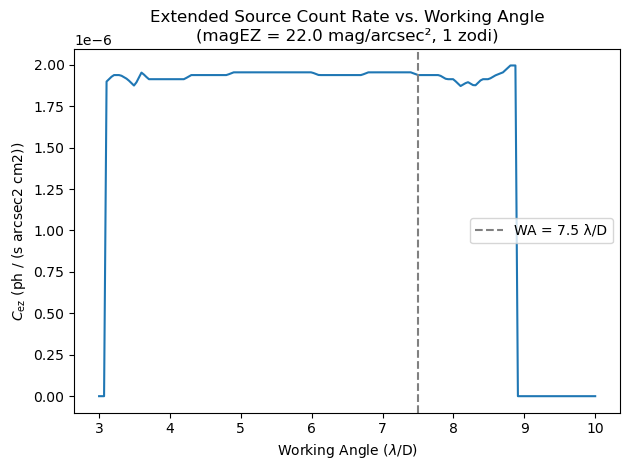

In [9]:
# Compute count rate across a range of working angles
WA_range = np.linspace(3, 10, 200) * lam_D
Omega_range = syst["core_area"](lam, WA_range)/syst["input_angle_unit_value"] ** 2
C_ez_range = fZ_ez * Omega_range

plt.figure()
plt.plot(WA_range / lam_D, C_ez_range)
plt.xlabel(r"Working Angle ($\lambda$/D)")
plt.ylabel(f"$C_{{\\rm ez}}$ ({C_ez_range.unit})")
plt.title("Extended Source Count Rate vs. Working Angle\n"
          f"(magEZ = {magEZ} mag/arcsec², 1 zodi)")
plt.axvline(7.5, color='gray', linestyle='--', label='WA = 7.5 λ/D')
plt.legend()
plt.tight_layout();

## Integration Time as a Function of Number of Zodis

Now we can compute the integration time required to detect the exozodiacal disk signal as a given SNR using OS.calc_intTime function. The disk signal enters the calculation exclusively through affecting the dMag (the brightness contrast of the disk relative to the host star).

$$\Delta\mathrm{mag} = -2.5 \log_{10}\left(\frac{F_{ez}}{F_\star}\right) = -2.5 \log_{10}\left(\frac{f_{Z,\mathrm{ez}} \times \Omega}{F_\star}\right)$$

The local zodiacal light enters as a background noise term via fZ, and the exozodiacal contribution is set to JEZ = 0 since we are treating the disk as the signal rather than a noise source, including it in both would double-count it.
As the number of zodis increases, the disk becomes brighter (smaller dMag), making it easier to detect and reducing the required integration time.

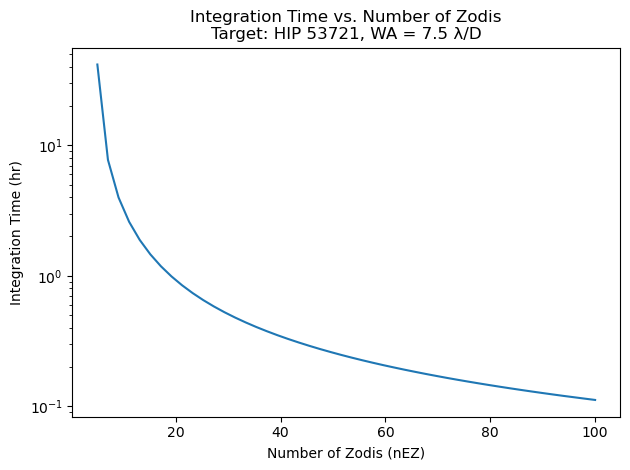

In [10]:
# Stellar flux for dMag computation
flux_star = TL.starFlux(sInd, mode)

# Physical exozodi surface brightness (with F0) for dMag computation
fZ_ez_physical = mode["F0"] * 10**(-magEZ / 2.5) / u.arcsec**2

# Local zodi background
fZ_local = np.repeat(ZL.fZ0, 1)

# Base JEZ at 1 zodi
JEZ0 = TL.JEZ0[mode["hex"]][sInd]

# Sweep nEZ from 1000 to 10000 (disk detectable range for this target)
nEZ_range = np.linspace(1, 100, 50)
intTimes = []

# Disk also contributes as noise via JEZ, scaled by nEZ
JEZ_nEZ = np.repeat(0 * JEZ0, 1)

for nEZ in nEZ_range:
    # Disk flux scaled by nEZ → affects dMag
    F_ez = nEZ * fZ_ez_physical * Omega  # ← nEZ applied here
    dMag = np.array([-2.5 * np.log10((F_ez / flux_star).decompose().value[0])])

    t = OS.calc_intTime(TL, sInd, fZ_local, JEZ_nEZ, dMag, WA, mode)
    intTimes.append(t.to(u.d).value[0])

intTimes = np.array(intTimes) * u.d

plt.figure()
plt.semilogy(nEZ_range, intTimes.to(u.hr))
plt.xlabel("Number of Zodis (nEZ)")
plt.ylabel("Integration Time (hr)")
plt.title(f"Integration Time vs. Number of Zodis\n"
          f"Target: {TL.Name[sInd][0]}, WA = 7.5 λ/D")
plt.tight_layout();